In [9]:
import pandas as pd

df = pd.read_csv("data/complaints.csv", nrows=1000)
print(df.shape)
print(df.columns.tolist())
df.head()

(1000, 2)
['Product', 'Consumer complaint narrative']


,Product,Consumer complaint narrative
0,Credit reporting or other personal consumer re...,"Despite multiple written requests, the unverif..."
1,Checking or savings account,My checking account has been open with Bank of...
2,Vehicle loan or lease,"Hello, My name is XXXX XXXX I am in a 72 month..."
3,Debt collection,In XXXX I purchased a XXXX XXXX from Exter fin...
4,"Credit reporting, credit repair services, or o...",Complaint : ( XXXX ) account # XXXXhas violate...


In [10]:
labels = pd.read_csv("data/complaints.csv", usecols=["Product"])
print(len(labels))
labels["Product"].value_counts().to_frame()

300000


,count
Product,
"Credit reporting, credit repair services, or other personal consumer reports",119057
Credit reporting or other personal consumer reports,55400
Debt collection,39443
Mortgage,17483
Credit card or prepaid card,15996
Checking or savings account,14930
Credit card,7510
Student loan,6570
"Money transfer, virtual currency, or money service",6213


In [11]:
df = pd.read_csv("data/complaints.csv")
print(df.isna().sum().to_frame())

                              0
Product                       0
Consumer complaint narrative  0


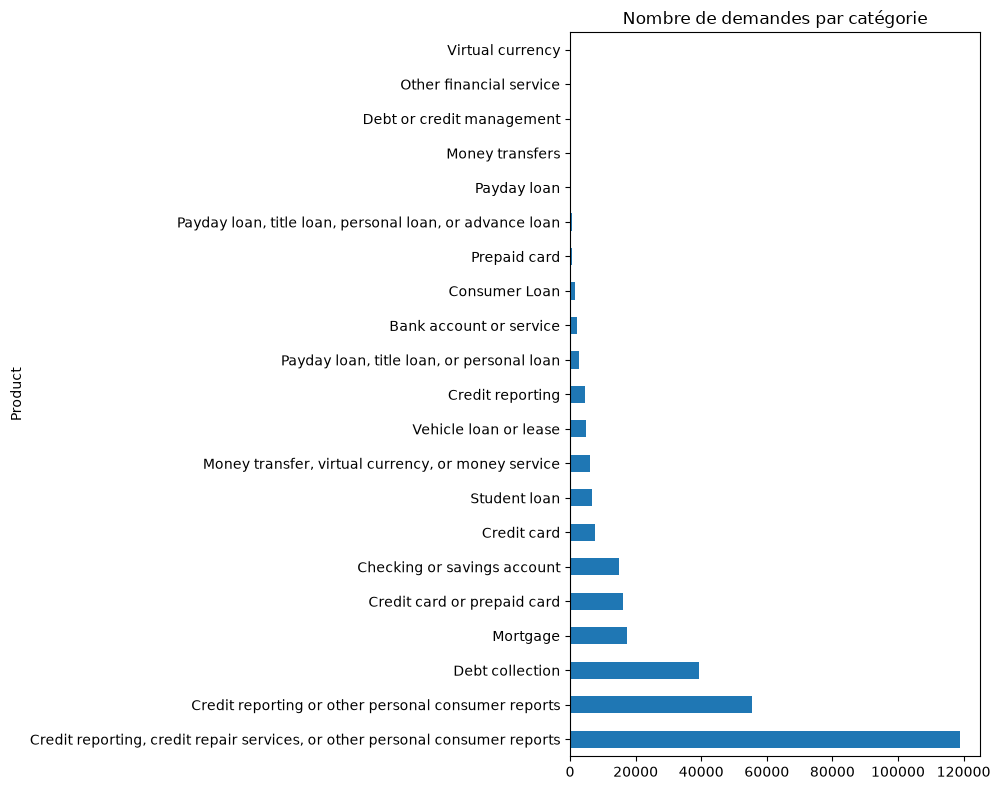

In [12]:
import matplotlib.pyplot as plt

df["Product"].value_counts().plot(kind="barh", figsize=(10, 8))
plt.title("Nombre de demandes par catégorie")
plt.tight_layout()
plt.show()

In [13]:
longueurs = df["Consumer complaint narrative"].str.len()
print(longueurs.describe())
print("Doublons :", df.duplicated().sum())

count    300000.000000
mean       1015.808033
std        1318.016849
min           9.000000
25%         343.000000
50%         661.000000
75%        1197.000000
max       32661.000000
Name: Consumer complaint narrative, dtype: float64
Doublons : 39644


In [14]:
df = df.drop_duplicates()

In [15]:
df["texte"] = (
    df["Consumer complaint narrative"]
    .str.replace(r"X{2,}", " ", regex=True)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

print(len(df))
df[["Product", "texte"]].head()

260356


,Product,texte
0,Credit reporting or other personal consumer re...,"Despite multiple written requests, the unverif..."
1,Checking or savings account,My checking account has been open with Bank of...
2,Vehicle loan or lease,"Hello, My name is I am in a 72 month contract ..."
3,Debt collection,In I purchased a from Exter finance and receiv...
4,"Credit reporting, credit repair services, or o...",Complaint : ( ) account # has violated 15 U.S....


In [16]:
df["Product"].value_counts().to_frame()

,count
Product,
"Credit reporting, credit repair services, or other personal consumer reports",101265
Credit reporting or other personal consumer reports,37433
Debt collection,36998
Mortgage,17477
Credit card or prepaid card,15479
Checking or savings account,14928
Credit card,6762
Student loan,6559
"Money transfer, virtual currency, or money service",6173


In [1]:
import sys
print(sys.version)

3.12.13 (main, May 10 2026, 19:30:01) [Clang 22.1.3 ]
